0 2.153773404383351
1 2.030085641973969
2 1.764122857704372
3 1.4386170190622813
4 1.1314693028008094
5 0.8874958590043782
6 0.6989439396466786
7 0.5633708361522363
8 0.47141212896510076
9 0.41173112286727864
10 0.36959756964126633
11 0.3400308290577261
12 0.3175395088466164
13 0.2981302356093565
14 0.28152268457583673
15 0.2665462275068826
16 0.25271320498889516
17 0.23975758575980421
18 0.2276676616354525
19 0.2161882114943765
20 0.20534753679722328
21 0.1950535300118208
22 0.18530085351123304
23 0.1760358108356712
24 0.16723402029388623
25 0.15887231927919032
26 0.15092870331523223
27 0.14338226814947141
28 0.13621315474199847
29 0.12940249700490014
30 0.12293237215465513
31 0.11678575354692278
32 0.1109464658695769
33 0.10539914257609784
34 0.10012918544729121
35 0.09512272617492812
36 0.09036658986618029
37 0.08584826037287119
38 0.0815558473542275
39 0.07747805498651772
40 0.0736041522371913
41 0.06992394462533191
42 0.06642774739406487
43 0.06310636002436176
44 0.059951042023143

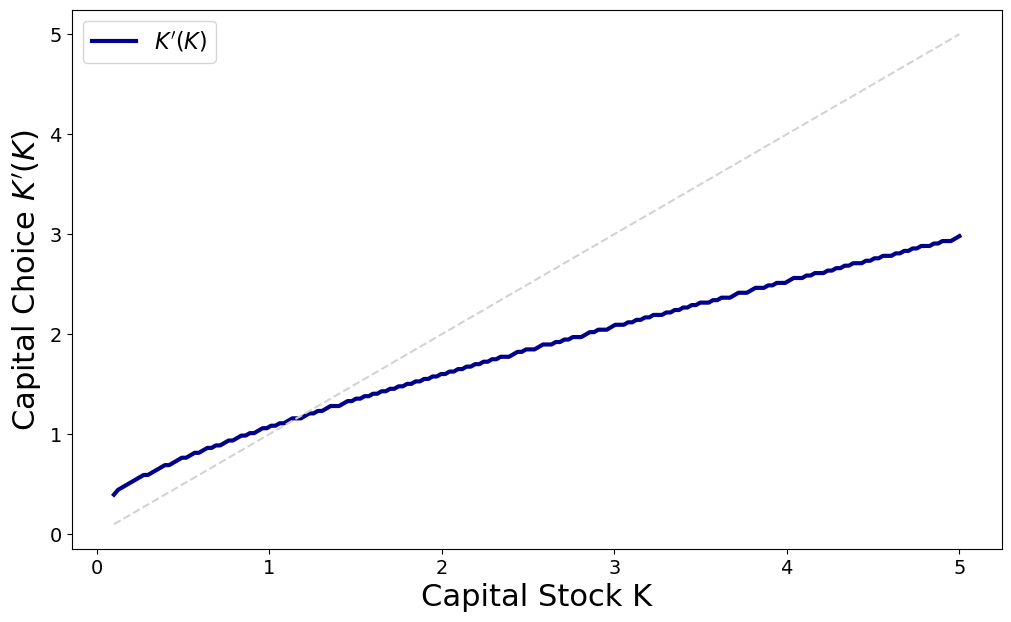

In [1]:
import numpy as np
from scipy import interpolate, optimize
import matplotlib.pyplot as plt

# Economic parameters
betta = 0.95
alpha = 0.3
delta = 0.1
sigma = 0.25
tau = 0.1
lamb = 0.0

# Grid parameters
k_min = 0.1
k_max = 5.0
nk = 200

# Technical parameters
maxiter = 10000
tol = 1e-6

# Initialization
kgrid = np.linspace(k_min,k_max,nk)

V_guess = ((delta * kgrid) ** (1 - sigma) - 1) / ((1 - sigma) * (1 - betta))
k_guess = np.zeros(nk)

# Main Loop
for iter0 in range(maxiter):

    V_new = np.zeros(nk)

    for ik in range(nk):

        transfer = lamb * tau * (kgrid[ik] ** alpha + (1 - delta) * kgrid[ik])

        con = (1 - tau) * (kgrid[ik] ** alpha + (1 - delta) * kgrid[ik]) - kgrid + transfer
        idx_con_pos = np.where(con > 0)

        util = np.ones(nk) * (-1e6)
        util[idx_con_pos] = (con[idx_con_pos] ** (1 - sigma) - 1) / (1 - sigma)

        T_op = util + betta * V_guess

        V_new[ik] = np.amax(T_op)
        idx_max = np.argmax(T_op)
        k_guess[ik] = kgrid[idx_max]

    metric = np.amax(np.abs(V_guess - V_new))
    print(iter0, metric)
    if (metric < tol):
        break

    V_guess = V_new.copy()

fig,ax=plt.subplots(figsize=(12,7))
ax.plot(kgrid,k_guess,color="darkblue",linewidth=3,label="$K'(K)$")
ax.plot(kgrid, kgrid, color='lightgrey', linestyle='dashed')

ax.set_ylabel("Capital Choice $K'(K)$", fontsize=22)
ax.set_xlabel("Capital Stock K", fontsize=22)
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)

plt.legend(fontsize= 16, loc='upper left')
plt.show()